## Build A Basic Chatbot With Langgraph(GRAPH API)

In [9]:
from typing_extensions import TypedDict
from typing import Annotated

from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [10]:
from dotenv import load_dotenv
load_dotenv()

True

In [11]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7be12c1c8b90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7be12c6039d0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [12]:
llm = init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7be10ae78180>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7be10ae78b00>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [13]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [15]:
graph_builder = StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)
graph = graph_builder.compile()

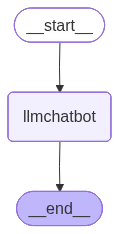

In [16]:
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
response = graph.invoke({"messages":"hi"})
response

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='98b00b12-501e-48ac-a5d6-81f5b783c4df'),
  AIMessage(content='<think>\nOkay, the user just said "hi". I need to respond appropriately. Let me think about the best way to reply.\n\nFirst, since it\'s a greeting, I should acknowledge it warmly. Maybe say "Hello!" to be friendly. Then, offer assistance to let them know I\'m here to help. Something like, "How can I assist you today?" would work.\n\nI should keep the tone positive and open-ended to encourage them to ask anything they need. Maybe add an emoji to make it more approachable, like a smiley face. Let me check if that\'s appropriate. Yeah, it seems friendly without being over the top.\n\nWait, should I mention anything else? Maybe not, since they just said hi. Let me keep it simple and concise. The user might have a specific question or need, so I want to make it easy for them to ask. Alright, the response should be:\n\n"Hello! How can I assist

In [20]:
response["messages"][-1].content

'<think>\nOkay, the user just said "hi". I need to respond appropriately. Let me think about the best way to reply.\n\nFirst, since it\'s a greeting, I should acknowledge it warmly. Maybe say "Hello!" to be friendly. Then, offer assistance to let them know I\'m here to help. Something like, "How can I assist you today?" would work.\n\nI should keep the tone positive and open-ended to encourage them to ask anything they need. Maybe add an emoji to make it more approachable, like a smiley face. Let me check if that\'s appropriate. Yeah, it seems friendly without being over the top.\n\nWait, should I mention anything else? Maybe not, since they just said hi. Let me keep it simple and concise. The user might have a specific question or need, so I want to make it easy for them to ask. Alright, the response should be:\n\n"Hello! How can I assist you today? 😊"\n</think>\n\nHello! How can I assist you today? 😊'

In [21]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user just greeted me with "Hi How are you?" I need to respond appropriately. First, I should acknowledge their greeting and express that I'm doing well. Since I'm an AI, I don't have feelings, but I can simulate a friendly response. I should keep the tone positive and open to encourage further interaction. Maybe add an emoji to make it more approachable. Also, I should ask how they're doing and offer assistance in case they need anything. Keep it concise but warm.
</think>

Hi there! I'm just a pile of code, but I'm functioning at 100%! 😊 How about you? I'd love to hear how you're doing and see if there's anything I can help with. Need advice, information, or just someone to chat with?


In [23]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=2)
tavily_tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. By treating workflows as interconnected nodes and edges, LangGraph offers a scalable, transparent and developer-friendly way to design advanced AI systems ranging from simple chatbots to multi-agent system. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. By designing workflows, users combine multiple nodes into powerful, dynamic AI processes. * ****langgraph:**** Framework for buil

In [24]:
## custom function tool 
def multiply(a :int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [25]:
tools = [tavily_tool, multiply]
llm_with_tool=llm.bind_tools(tools)
llm_with_tool

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7be10ae78180>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7be10ae78b00>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, acc

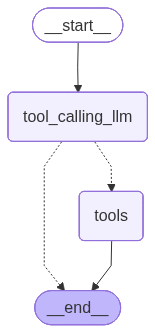

In [26]:
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode,tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
response = graph.invoke({"messages": "what is the latest ai news"})
response["messages"][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bloomberg.com/news/articles/2026-04-24/deepseek-unveils-newest-flagship-a-year-after-ai-breakthrough", "title": "DeepSeek Unveils Flagship AI Model a Year After Breakthrough - Bloomberg.com", "score": 0.9755769, "published_date": "Fri, 24 Apr 2026 04:54:21 GMT", "content": "China’s AI Power Grab. # DeepSeek Unveils Flagship AI Model a Year After Breakthrough. Provide news feedback or report an error. Send a tip to our reporters. ## **Takeaways** by Bloomberg AI. DeepSeek rolled out preview versions of a new flagship artificial intelligence model a year after upending Silicon Valley, calling it the most powerful open-source platform in a challenge to rivals from OpenAI to Anthropic PBC. The Chinese startup unveiled the V4 Flash and V4 Pro series, touting top-tier performance in coding benchmarks and big advancements in reasoning and agentic tasks. They come with archi

In [28]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the latest ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (h4ezw5y1h)
 Call ID: h4ezw5y1h
  Args:
    query: latest AI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bloomberg.com/news/articles/2026-04-24/deepseek-unveils-newest-flagship-a-year-after-ai-breakthrough", "title": "DeepSeek Unveils Flagship AI Model a Year After Breakthrough - Bloomberg.com", "score": 0.9755769, "published_date": "Fri, 24 Apr 2026 04:54:21 GMT", "content": "China’s AI Power Grab. # DeepSeek Unveils Flagship AI Model a Year After Breakthrough. Provide news feedback or report an error. Send a tip to our reporters. ## **Takeaways** by Bloo

In [29]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (z3ew7vsbz)
 Call ID: z3ew7vsbz
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [30]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (1dqhrycxw)
 Call ID: 1dqhrycxw
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
  multiply (6ngrvcz7y)
 Call ID: 6ngrvcz7y
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnet.com/tech/services-and-software/ai-arms-race-accelerates-with-new-models-from-openai-deepseek-and-anthropic/", "title": "AI Arms Race Accelerates With New Models from OpenAI, DeepSeek and Anthropic - CNET", "score": 0.6241337, "published_date": "Fri, 24 Apr 2026 19:48:00 GMT", "content": "The newest offerings, DeepSeek's V4 Flas